In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=False)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

merged_path = "scarf_datasets/kang_integration_metrics.zarr"
scarf.AssayMerge(
    zarr_path=merged_path,
    assays=[ds_ctrl.RNA, ds_stim.RNA],
    names=["ctrl", "stim"],
    merge_assay_name="RNA",
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()
ds = scarf.DataStore(merged_path, nthreads=4)
ds.mark_hvgs(
    min_cells=10,
    top_n=2000,
    min_mean=-3,
    max_mean=2,
    max_var=6,
    show_plot=False,
)
normalized = ds.run_normalization(feat_key="hvgs")
pca = ds.run_pca(normalized, dims=25)

In [2]:
def evaluate_graph(cluster_label):
    lisi = dict(
        ds.metric_lisi(
            label_colnames=["sample_id", "orig_cluster_labels"],
            perplexity=7,
        )
    )
    silhouette = ds.metric_graph_silhouette(
        res_label=cluster_label,
    )
    return {
        "batch LISI median": float(np.median(lisi["sample_id"])),
        "cell-type LISI median": float(
            np.median(lisi["orig_cluster_labels"])
        ),
        "iLISI": ds.metric_ilisi(
            batch_colname="sample_id",
            perplexity=7,
        ),
        "cLISI": ds.metric_clisi(
            label_colname="orig_cluster_labels",
            perplexity=7,
        ),
        "proportional mixing": (
            ds.metric_proportional_batch_mixing(
                label_colname="sample_id",
                perplexity=7,
            )
        ),
        "graph connectivity": ds.metric_graph_connectivity(
            label_colname="orig_cluster_labels",
        ),
        "label ARI": ds.metric_label_concordance(
            label_columns=[
                f"RNA_{cluster_label}",
                "orig_cluster_labels",
            ],
            metric="ari",
        ),
        "mean graph silhouette": float(np.nanmean(silhouette)),
    }

In [3]:
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(pca)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="metrics_uncorrected_UMAP",
)
ds.run_leiden_clustering(
    resolution=1.0,
    label="metrics_uncorrected_clusters",
)
uncorrected_metrics = evaluate_graph(
    "metrics_uncorrected_clusters"
)

In [4]:
corrected = ds.run_harmony(["sample_id"], pca)
ds.build_embedding_initialization(pca)
ann = ds.build_ann_index(corrected)
neighbors = ds.query_neighbors(ann, k=21)
ds.build_connectivity_map(neighbors)
ds.run_umap(
    n_epochs=250,
    spread=5,
    min_dist=1,
    parallel=True,
    label="metrics_harmony_UMAP",
)
ds.run_leiden_clustering(
    resolution=1.0,
    label="metrics_harmony_clusters",
)
harmony_metrics = evaluate_graph("metrics_harmony_clusters")

In [5]:
metric_frame = pd.DataFrame(
    {
        "uncorrected": uncorrected_metrics,
        "Harmony": harmony_metrics,
    }
).T
metric_frame.round(3)

,batch LISI median,cell-type LISI median,iLISI,cLISI,proportional mixing,graph connectivity,label ARI,mean graph silhouette
uncorrected,1.000,1.012,0.000,0.999,0.030,0.944,0.419,0.202
Harmony,1.483,1.014,0.483,0.999,0.507,0.956,0.469,0.220


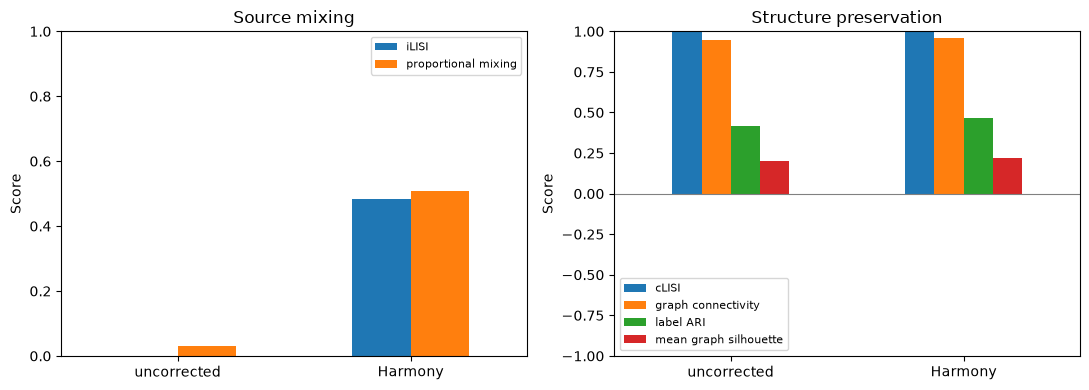

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
metric_frame[
    [
        "iLISI",
        "proportional mixing",
    ]
].plot.bar(ax=axes[0], title="Source mixing")
metric_frame[
    [
        "cLISI",
        "graph connectivity",
        "label ARI",
        "mean graph silhouette",
    ]
].plot.bar(ax=axes[1], title="Structure preservation")
for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.legend(fontsize=8)
    ax.set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[1].set_ylim(-1, 1)
axes[1].axhline(0, color="0.5", linewidth=0.8)
fig.tight_layout()

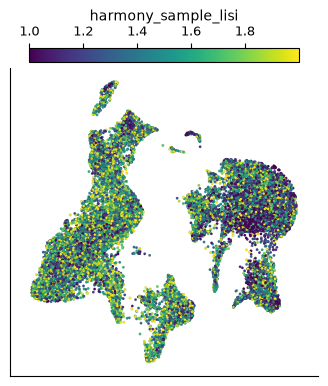

In [7]:
harmony_lisi = dict(
    ds.metric_lisi(
        label_colnames=["sample_id"],
        perplexity=7,
    )
)["sample_id"]
ds.cells.insert(
    "harmony_sample_lisi",
    harmony_lisi,
    key="I",
    overwrite=True,
)
ds.plots.embedding(
    layout_key="RNA_metrics_harmony_UMAP",
    color_by="harmony_sample_lisi",
)